In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("VitaminD_Dataset.csv")

df = df.drop(["Skin_tone", "Sunscreen_Use"], axis=1)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 15)


,Age,Gender,Weight_kg,Height_cm,BMI,BodyFat_percent,Sun_Exposure_min,Skin_Exposure_percent,Alcohol_units_week,Fish_intake_week,Dairy_intake_week,Physical_activity_hours_week,Indoor_work_hours_day,VitaminD_Level_ng_ml,VitaminD_Category
0,63,0,72.3,167.2,25.9,40.2,5,34,2,3,5,4.8,7.3,7.7,Deficient
1,20,0,81.9,168.4,28.9,33.9,39,63,1,2,5,2.0,6.7,28.0,Insufficient
2,46,1,79.5,160.8,30.7,31.2,7,36,1,4,4,4.5,4.0,12.1,Deficient
3,52,1,51.2,171.5,17.4,16.6,46,20,5,1,4,1.8,10.7,18.7,Deficient
4,56,0,60.2,155.4,24.9,37.4,5,53,0,5,1,6.3,6.9,19.6,Deficient


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           10000 non-null  int64  
 1   Gender                        10000 non-null  int64  
 2   Weight_kg                     10000 non-null  float64
 3   Height_cm                     10000 non-null  float64
 4   BMI                           10000 non-null  float64
 5   BodyFat_percent               10000 non-null  float64
 6   Sun_Exposure_min              10000 non-null  int64  
 7   Skin_Exposure_percent         10000 non-null  int64  
 8   Alcohol_units_week            10000 non-null  int64  
 9   Fish_intake_week              10000 non-null  int64  
 10  Dairy_intake_week             10000 non-null  int64  
 11  Physical_activity_hours_week  10000 non-null  float64
 12  Indoor_work_hours_day         10000 non-null  float64
 13  Vi

Age                             0
Gender                          0
Weight_kg                       0
Height_cm                       0
BMI                             0
BodyFat_percent                 0
Sun_Exposure_min                0
Skin_Exposure_percent           0
Alcohol_units_week              0
Fish_intake_week                0
Dairy_intake_week               0
Physical_activity_hours_week    0
Indoor_work_hours_day           0
VitaminD_Level_ng_ml            0
VitaminD_Category               0
dtype: int64

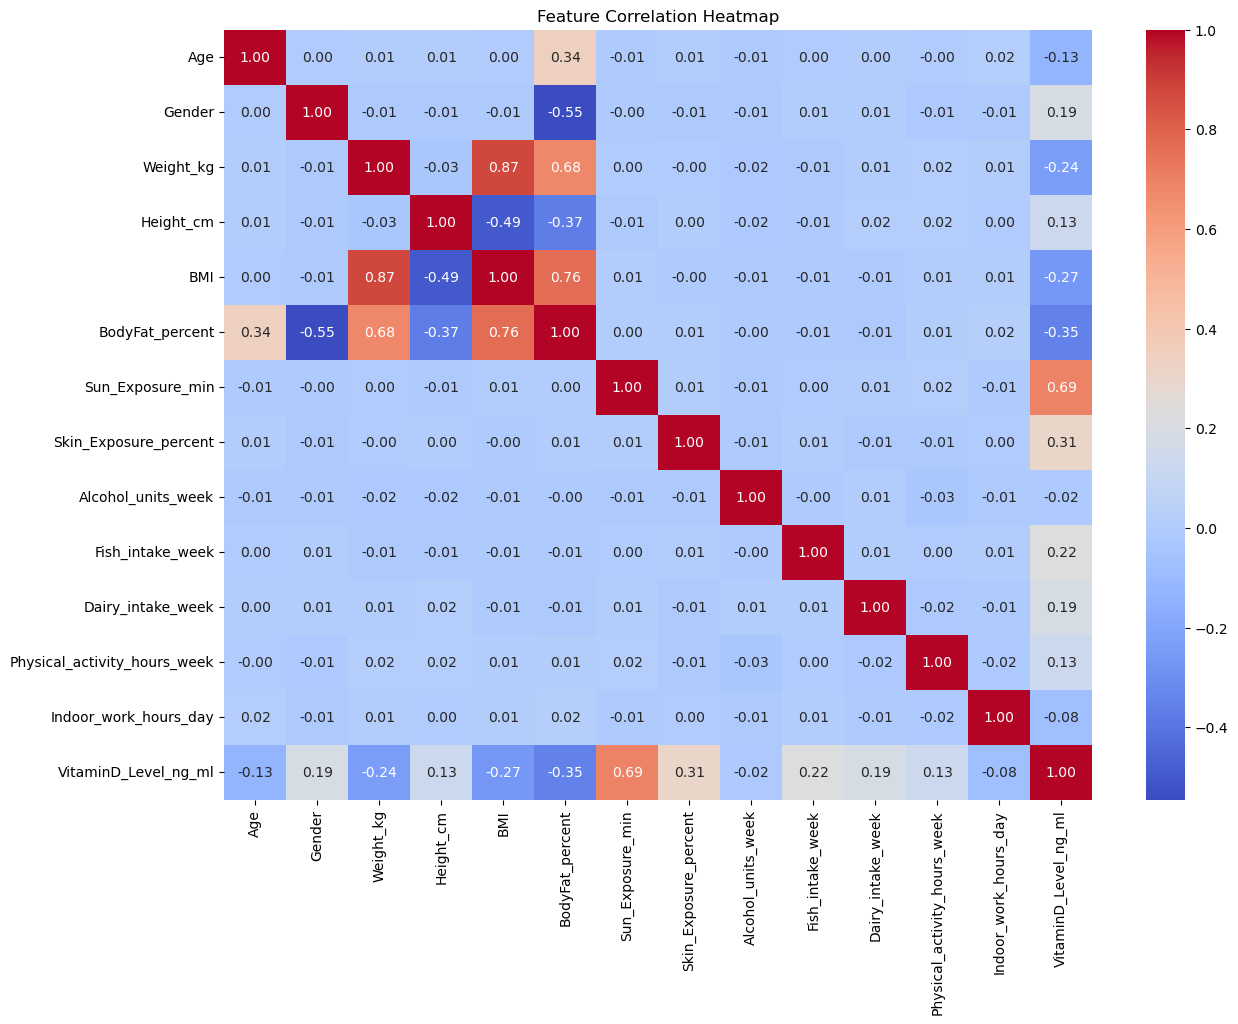

In [4]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
label = LabelEncoder()

df["Gender"] = label.fit_transform(df["Gender"])


In [7]:
print(df.columns)

Index(['Age', 'Gender', 'Weight_kg', 'Height_cm', 'BMI', 'BodyFat_percent',
       'Sun_Exposure_min', 'Skin_Exposure_percent', 'Alcohol_units_week',
       'Fish_intake_week', 'Dairy_intake_week', 'Physical_activity_hours_week',
       'Indoor_work_hours_day', 'VitaminD_Level_ng_ml', 'VitaminD_Category'],
      dtype='object')


In [42]:
df = df.drop(["VitaminD_Category"], axis=1, errors="ignore")

In [43]:
X = df.drop("VitaminD_Level_ng_ml", axis=1)

# Convert categorical feature columns to numeric dummy variables for sklearn models.
X = pd.get_dummies(X, drop_first=True)

y = pd.to_numeric(df["VitaminD_Level_ng_ml"], errors="coerce")

# If target values are categorical (e.g., Deficient/Sufficient), encode them to integers.
if y.isna().any():
    target_encoder = LabelEncoder()
    y = pd.Series(
        target_encoder.fit_transform(df["VitaminD_Level_ng_ml"].astype(str)),
        index=df.index
    )
    print("Encoded target classes:", list(target_encoder.classes_))

print("Features used:")
print(X.columns)

Features used:
Index(['Age', 'Gender', 'Weight_kg', 'Height_cm', 'BMI', 'BodyFat_percent',
       'Sun_Exposure_min', 'Skin_Exposure_percent', 'Alcohol_units_week',
       'Fish_intake_week', 'Dairy_intake_week', 'Physical_activity_hours_week',
       'Indoor_work_hours_day'],
      dtype='object')


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (8000, 13)
Testing samples: (2000, 13)


In [45]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Results")

print("R2 Score:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear Regression Results
R2 Score: 0.787506544656003
MAE: 3.405812394348603
RMSE: 4.266162467726401


In [46]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [47]:
print("Random Forest Results")

print("R2 Score:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest Results
R2 Score: 0.7527804428650661
MAE: 3.6807327499999998
RMSE: 4.601569897939724


In [48]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.787507
1,Random Forest,0.752780


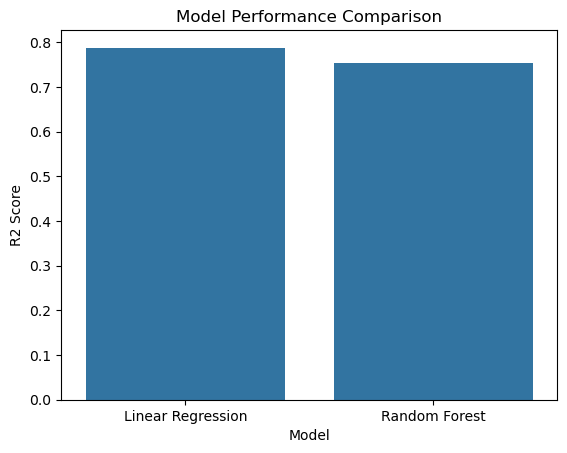

In [49]:
sns.barplot(x="Model", y="R2 Score", data=results)

plt.title("Model Performance Comparison")
plt.show()

In [50]:
importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,Sun_Exposure_min,0.498257
5,BodyFat_percent,0.151719
7,Skin_Exposure_percent,0.114644
9,Fish_intake_week,0.044298
11,Physical_activity_hours_week,0.037035
10,Dairy_intake_week,0.036686
12,Indoor_work_hours_day,0.025958
3,Height_cm,0.021446
0,Age,0.020058
2,Weight_kg,0.019463


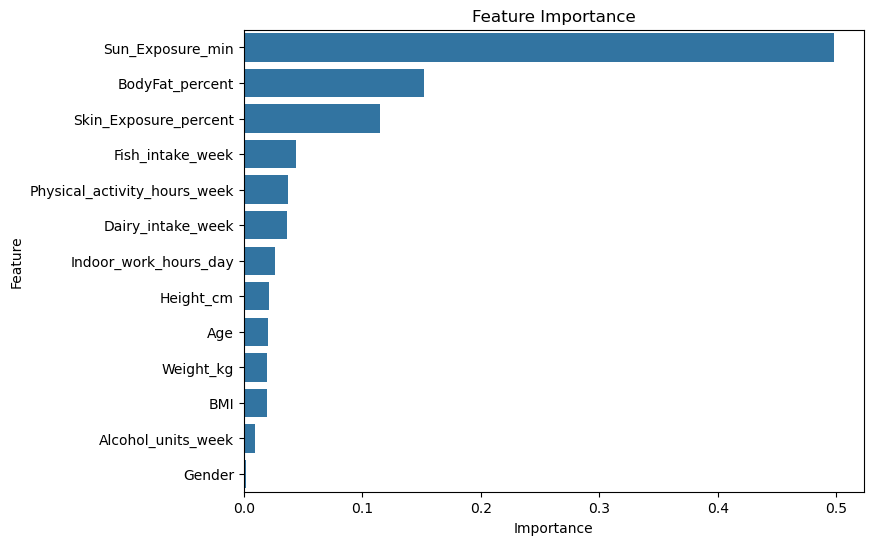

In [51]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

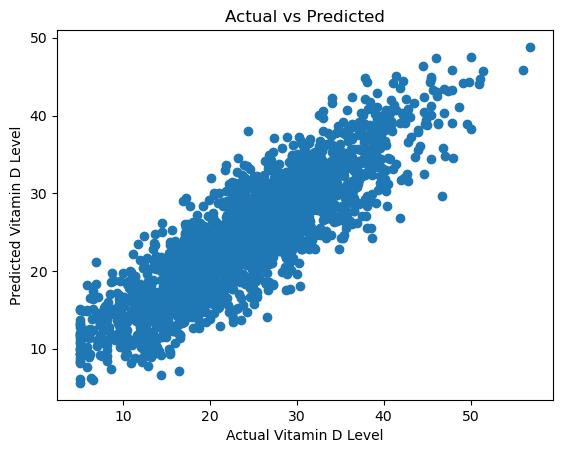

In [52]:
plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Vitamin D Level")
plt.ylabel("Predicted Vitamin D Level")

plt.title("Actual vs Predicted")

plt.show()

In [56]:
new_person = pd.DataFrame({
    "Age": [25],
    "Gender": [1],
    "BMI": [23],
    "BodyFat_percent": [18],
    "Sun_Exposure_min": [30],
    "Skin_Exposure_percent": [40],
    "Fish_intake_week": [2],
    "Dairy_intake_week": [4],
    "Alcohol_units_week": [1],
    "Physical_activity_hours_week": [3],
    "Indoor_work_hours_day": [6]
})

# Align to model training schema: add missing columns with 0 and keep only expected columns.
new_person = new_person.reindex(columns=X.columns, fill_value=0)

prediction = rf.predict(new_person)

print("Predicted Vitamin D Level:", prediction[0])

def classify_vitamin_d(level):
    if level < 20:
        return "Deficient"
    elif level < 30:
        return "Insufficient"
    else:
        return "Sufficient"

level = prediction[0]

print("Predicted Vitamin D Level:", level)
print("Vitamin D Status:", classify_vitamin_d(level))

Predicted Vitamin D Level: 25.655
Predicted Vitamin D Level: 25.655
Vitamin D Status: Insufficient
